In [1]:
import numpy as np
import matplotlib.pyplot as plt

from importlib import reload
import qubo_utils
reload(qubo_utils)

<module 'qubo_utils' from '/Users/snehaesther/Desktop/sqa/qubo/qubo_utils.py'>

In [2]:
import importlib
import qubo_utils

importlib.reload(qubo_utils)

<module 'qubo_utils' from '/Users/snehaesther/Desktop/sqa/qubo/qubo_utils.py'>

In [3]:
from qubo_utils import build_multi_Q_strict

Solver Utility Functions

In [4]:
import itertools
import numpy as np


def check_validity(bits, edges, nodes, targets):
    active_edges = [edges[i] for i in range(len(edges)) if bits[i] == 1]

    if not active_edges:
        return False

    for v in nodes:
        in_degree = sum(1 for u, w in active_edges if w == v)
        out_degree = sum(1 for u, w in active_edges if u == v)

        if (out_degree - in_degree) != targets[v]:
            return False

    return True


def get_path_string(bits, edge_names):
    chosen = [
        edge_names[i]
        for i in range(len(edge_names))
        if bits[i] == 1
    ]
    return " -> ".join(chosen) if chosen else "No Path"


def brute_force(Q, costs, edges, nodes, targets):
    num_vars = Q.shape[0]

    valid_results = []

    for bits in itertools.product([0,1], repeat=num_vars):
        x = np.array(bits)

        energy = x.T @ Q @ x

        if check_validity(bits, edges, nodes, targets):

            path_cost = sum(
                costs[i]
                for i in range(len(edges))
                if bits[i] == 1
            )

            valid_results.append({
                "bits": bits,
                "energy": energy,
                "path_cost": path_cost
            })

    best = min(valid_results, key=lambda r: r["energy"])

    return best

In [5]:
import matplotlib.pyplot as plt
import itertools
import numpy as np


def make_plot(Q, costs, edges, nodes, targets):
    num_vars = Q.shape[0]

    results = []

    for bits in itertools.product([0,1], repeat=num_vars):
        x = np.array(bits)

        energy = x.T @ Q @ x

        valid = check_validity(bits, edges, nodes, targets)

        path_cost = sum(
            costs[i]
            for i in range(len(edges))
            if bits[i] == 1
        )

        results.append({
            "energy": energy,
            "valid": valid,
            "path_cost": path_cost
        })

    valid_results = [r for r in results if r["valid"]]
    best = min(valid_results, key=lambda r: r["energy"])

    x_vals = [r["path_cost"] for r in results]
    y_vals = [r["energy"] for r in results]
    colors = ["green" if r["valid"] else "red" for r in results]

    plt.figure(figsize=(10,6))
    plt.scatter(x_vals, y_vals, c=colors, s=20)

    plt.title("Energy vs Path Cost")
    plt.xlabel("Path Cost")
    plt.ylabel("Energy")
    plt.grid(True, alpha=0.3)
    plt.axhline(best["energy"], linestyle="--", label="Min Valid Energy")
    plt.legend()
    plt.show()

In [6]:
edges = [(0,1), (0,2), (1,2), (1,3), (2,3)]
costs = [2.5, 5.0, 1.0, 3.0, 1.5]
nodes = [0,1,2,3]
targets = {0:1, 1:0, 2:0, 3:-1}

Q = qubo_utils.build_Q(costs, edges, nodes, targets)
print(Q)

[[   2.5  400.  -400.  -400.     0. ]
 [   0.     5.   400.     0.  -400. ]
 [   0.     0.   401.   400.  -400. ]
 [   0.     0.     0.     3.   400. ]
 [   0.     0.     0.     0.     1.5]]


--- VALIDATION RESULTS ---
Lowest VALID Energy: -395.0
Best Configuration: (1, 0, 1, 0, 1)
Human Readable Path: AB -> BC -> CD
Path Length: 5.0


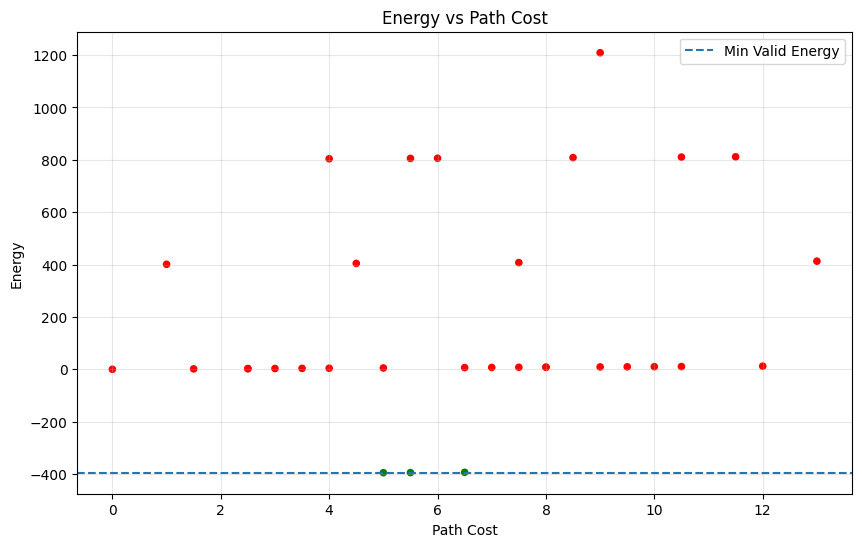

In [7]:
import matplotlib.pyplot as plt
import itertools
import numpy as np

# --- SETUP GRAPH ---
edges = [(0,1), (0,2), (1,2), (1,3), (2,3)]
edge_names = ["AB", "AC", "BC", "BD", "CD"]

costs = [2.5, 5.0, 1.0, 3.0, 1.5]

nodes = [0,1,2,3]

targets = {0:1, 1:0, 2:0, 3:-1}

# Build QUBO
Q = qubo_utils.build_Q(costs, edges, nodes, targets)

# Solve
best = brute_force(Q, costs, edges, nodes, targets)

# Output
print("--- VALIDATION RESULTS ---")
print("Lowest VALID Energy:", best["energy"])
print("Best Configuration:", best["bits"])
print("Human Readable Path:", get_path_string(best["bits"], edge_names))
print("Path Length:", best["path_cost"])

make_plot(Q, costs, edges, nodes, targets)


In [8]:
import random

def classical_shortest_path(costs):
    candidates = [
        costs[0] + costs[3],                 # AB -> BD
        costs[1] + costs[4],                 # AC -> CD
        costs[0] + costs[2] + costs[4]      # AB -> BC -> CD
    ]
    return min(candidates)


def test_run():
    edges = [(0,1), (0,2), (1,2), (1,3), (2,3)]
    edge_names = ["AB","AC","BC","BD","CD"]
    nodes = [0,1,2,3]
    targets = {0:1,1:0,2:0,3:-1}

    costs = [random.randint(1,9) for _ in range(5)]

    Q = qubo_utils.build_Q(costs, edges, nodes, targets)

    best = brute_force(Q, costs, edges, nodes, targets)

    qubo_cost = best["path_cost"]
    classical_cost = classical_shortest_path(costs)

    status = "PASS" if qubo_cost == classical_cost else "FAIL"

    print("Costs:", costs)
    print("QUBO Cost:", qubo_cost)
    print("Classical Cost:", classical_cost)
    print("Result:", status)

## Larger Graph Test (5 Nodes)
Testing generalized build_Q() on a bigger graph.

In [9]:
edges = [
    (0,1),
    (0,2),
    (1,2),
    (1,3),
    (2,3),
    (2,4),
    (3,4)
]

edge_names = ["01","02","12","13","23","24","34"]

costs = [2,4,1,3,2,5,1]

nodes = [0,1,2,3,4]

targets = {
    0: 1,   # source
    4: -1,  # sink
    1: 0,
    2: 0,
    3: 0
}

Q = qubo_utils.build_Q(costs, edges, nodes, targets)
print(Q.shape)
print(Q)

(7, 7)
[[   2.  400. -400. -400.    0.    0.    0.]
 [   0.    4.  400.    0. -400. -400.    0.]
 [   0.    0.  401.  400. -400. -400.    0.]
 [   0.    0.    0.  403.  400.    0. -400.]
 [   0.    0.    0.    0.  402.  400. -400.]
 [   0.    0.    0.    0.    0.    5.  400.]
 [   0.    0.    0.    0.    0.    0.    1.]]


Verify solver still finds correct shortest valid path on larger graph.

In [10]:
import itertools
import numpy as np

num_vars = Q.shape[0]

def check_validity(bits, edges, nodes, targets):
    active_edges = [edges[i] for i in range(len(edges)) if bits[i] == 1]

    if not active_edges:
        return False

    for v in nodes:
        in_degree = sum(1 for u, w in active_edges if w == v)
        out_degree = sum(1 for u, w in active_edges if u == v)

        if (out_degree - in_degree) != targets[v]:
            return False

    return True


def get_path_string(bits, edge_names):
    chosen = [
        edge_names[i]
        for i in range(len(edge_names))
        if bits[i] == 1
    ]
    return " -> ".join(chosen) if chosen else "No Path"


results = []

for bits in itertools.product([0,1], repeat=num_vars):
    x = np.array(bits)

    energy = x.T @ Q @ x
    valid = check_validity(bits, edges, nodes, targets)

    path_cost = sum(costs[i] for i in range(len(edges)) if bits[i] == 1)

    results.append((bits, energy, valid, path_cost))

valid_results = [r for r in results if r[2]]

best = min(valid_results, key=lambda x: x[1])

print("Lowest VALID Energy:", best[1])
print("Best Configuration:", best[0])
print("Chosen Path:", get_path_string(best[0], edge_names))
print("Path Cost:", best[3])

Lowest VALID Energy: -394.0
Best Configuration: (1, 0, 0, 1, 0, 0, 1)
Chosen Path: 01 -> 13 -> 34
Path Cost: 6


Batch Validation with Random Edge Weights

In [11]:
import random
import itertools
import numpy as np

# fixed graph structure
edges = [
    (0,1),
    (0,2),
    (1,2),
    (1,3),
    (2,3),
    (2,4),
    (3,4)
]

edge_names = ["01","02","12","13","23","24","34"]
nodes = [0,1,2,3,4]

targets = {0:1, 1:0, 2:0, 3:0, 4:-1}


def classical_paths(costs):
    candidates = {
        "01->13->34": costs[0] + costs[3] + costs[6],
        "02->24": costs[1] + costs[5],
        "01->12->24": costs[0] + costs[2] + costs[5],
        "01->12->23->34": costs[0] + costs[2] + costs[4] + costs[6],
        "02->23->34": costs[1] + costs[4] + costs[6],
    }
    return min(candidates.values())


for test in range(10):

    costs = [random.randint(1,9) for _ in range(len(edges))]

    Q = qubo_utils.build_Q(costs, edges, nodes, targets)

    num_vars = Q.shape[0]

    results = []

    for bits in itertools.product([0,1], repeat=num_vars):
        x = np.array(bits)

        energy = x.T @ Q @ x

        active_edges = [edges[i] for i in range(len(edges)) if bits[i] == 1]

        valid = True
        if not active_edges:
            valid = False

        for v in nodes:
            indeg = sum(1 for u,w in active_edges if w == v)
            outdeg = sum(1 for u,w in active_edges if u == v)

            if outdeg - indeg != targets[v]:
                valid = False

        if valid:
            path_cost = sum(costs[i] for i in range(len(edges)) if bits[i] == 1)
            results.append((energy, path_cost))

    best = min(results, key=lambda x: x[0])

    qubo_cost = best[1]
    classical_cost = classical_paths(costs)

    status = "PASS" if qubo_cost == classical_cost else "FAIL"

    print(f"Test {test+1}: costs={costs} | QUBO={qubo_cost} | Classical={classical_cost} --> {status}")

Test 1: costs=[9, 9, 7, 5, 1, 8, 4] | QUBO=14 | Classical=14 --> PASS
Test 2: costs=[6, 3, 2, 5, 8, 4, 5] | QUBO=7 | Classical=7 --> PASS
Test 3: costs=[1, 2, 5, 9, 2, 8, 9] | QUBO=10 | Classical=10 --> PASS
Test 4: costs=[7, 2, 3, 4, 5, 6, 7] | QUBO=8 | Classical=8 --> PASS
Test 5: costs=[8, 7, 1, 5, 9, 9, 2] | QUBO=15 | Classical=15 --> PASS
Test 6: costs=[8, 7, 1, 7, 1, 4, 9] | QUBO=11 | Classical=11 --> PASS
Test 7: costs=[9, 9, 4, 2, 8, 5, 5] | QUBO=14 | Classical=14 --> PASS
Test 8: costs=[5, 5, 4, 7, 6, 4, 4] | QUBO=9 | Classical=9 --> PASS
Test 9: costs=[3, 8, 4, 3, 8, 4, 1] | QUBO=7 | Classical=7 --> PASS
Test 10: costs=[7, 1, 1, 8, 6, 7, 8] | QUBO=8 | Classical=8 --> PASS


Two Simultaneous Paths Prototype

In [12]:
Q_single = qubo_utils.build_Q(costs, edges, nodes, targets)

n = Q_single.shape[0]
m = len(edges)          # number of real edge variables only

Q_two = np.zeros((2*n, 2*n))

# route 1 block
Q_two[:n, :n] = Q_single

# route 2 block
Q_two[n:, n:] = Q_single

# shared-edge penalty
Pc = 50

for e in range(m):
    Q_two[e, n + e] += Pc

print(Q_two.shape)
print(Q_two)

(14, 14)
[[   7.  400. -400. -400.    0.    0.    0.   50.    0.    0.    0.    0.
     0.    0.]
 [   0.    1.  400.    0. -400. -400.    0.    0.   50.    0.    0.    0.
     0.    0.]
 [   0.    0.  401.  400. -400. -400.    0.    0.    0.   50.    0.    0.
     0.    0.]
 [   0.    0.    0.  408.  400.    0. -400.    0.    0.    0.   50.    0.
     0.    0.]
 [   0.    0.    0.    0.  406.  400. -400.    0.    0.    0.    0.   50.
     0.    0.]
 [   0.    0.    0.    0.    0.    7.  400.    0.    0.    0.    0.    0.
    50.    0.]
 [   0.    0.    0.    0.    0.    0.    8.    0.    0.    0.    0.    0.
     0.   50.]
 [   0.    0.    0.    0.    0.    0.    0.    7.  400. -400. -400.    0.
     0.    0.]
 [   0.    0.    0.    0.    0.    0.    0.    0.    1.  400.    0. -400.
  -400.    0.]
 [   0.    0.    0.    0.    0.    0.    0.    0.    0.  401.  400. -400.
  -400.    0.]
 [   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  408.  400.
     0. -400.]
 [   0.    0

In [13]:
print("Populated QUBO Matrix Q:\n", Q)

Populated QUBO Matrix Q:
 [[   7.  400. -400. -400.    0.    0.    0.]
 [   0.    1.  400.    0. -400. -400.    0.]
 [   0.    0.  401.  400. -400. -400.    0.]
 [   0.    0.    0.  408.  400.    0. -400.]
 [   0.    0.    0.    0.  406.  400. -400.]
 [   0.    0.    0.    0.    0.    7.  400.]
 [   0.    0.    0.    0.    0.    0.    8.]]


In [14]:
import random

print("Running robustness test with random edge costs...\n")

for i in range(5):
    random_costs = [round(random.uniform(1, 10), 1) for _ in range(5)]

    shortest_path = min(random_costs[0] + random_costs[3],   # AB + BD
                        random_costs[1] + random_costs[4],   # AC + CD
                        random_costs[0] + random_costs[2] + random_costs[4]) # AB+BC+CD

    print(f"Test {i+1}: Costs = {random_costs}")
    print(f"Expected shortest path length = {shortest_path}")
    print("-" * 40) 

Running robustness test with random edge costs...

Test 1: Costs = [4.3, 9.6, 5.7, 1.0, 1.6]
Expected shortest path length = 5.3
----------------------------------------
Test 2: Costs = [1.1, 6.8, 7.0, 1.2, 9.0]
Expected shortest path length = 2.3
----------------------------------------
Test 3: Costs = [1.4, 3.5, 6.3, 8.0, 4.1]
Expected shortest path length = 7.6
----------------------------------------
Test 4: Costs = [6.4, 9.8, 9.9, 8.6, 4.0]
Expected shortest path length = 13.8
----------------------------------------
Test 5: Costs = [6.1, 2.8, 4.5, 7.2, 5.4]
Expected shortest path length = 8.2
----------------------------------------


Below we are using different random weights 

In [15]:
import numpy as np
import itertools
import random

def run_stress_test_with_flow(iterations=10):
    # Graph Definition
    edges = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)] # AB, AC, BC, BD, CD
    edge_names = ["AB", "AC", "BC", "BD", "CD"]
    nodes = [0, 1, 2, 3] # A, B, C, D
    targets = {0: 1, 3: -1, 1: 0, 2: 0} # A=Source, D=Sink
    num_vars = 7
    P1, P2 = 20, 20 # Penalty weights

    success_count = 0

    print(f"--- STARTING STRESS TEST ({iterations} iterations) ---")

    for run_idx in range(iterations):
        # 1. Generate Random Weights for this specific run
        test_costs = [round(random.uniform(1.0, 10.0), 2) for _ in range(5)]
        
        # 2. Re-build the Q Matrix from scratch for these weights
        Q_test = np.zeros((num_vars, num_vars))

        # Add Edge Costs to Diagonal
        for i in range(len(test_costs)):
            Q_test[i, i] += test_costs[i]

        # Add P1 (Flow Conservation)
        for v in nodes:
            conn = []
            for i, (u, w) in enumerate(edges):
                if u == v: conn.append((i, 1))
                elif w == v: conn.append((i, -1))
            
            Tv = targets[v]
            for i, s_vi in conn:
                Q_test[i, i] += P1 * (1 - 2 * Tv * s_vi)
                for j, s_vj in conn:
                    if i < j: Q_test[i, j] += 2 * P1 * s_vi * s_vj

        # Add P2 (Intermediate Node Degree)
        for v in [1, 2]: # Nodes B and C
            y_idx = 5 if v == 1 else 6
            conn = [i for i, (u, w) in enumerate(edges) if u == v or w == v]
            for i in conn:
                Q_test[i, i] += P2
                for j in conn:
                    if i < j: Q_test[i, j] += 2 * P2
            for i in conn:
                Q_test[i, y_idx] -= 4 * P2
            Q_test[y_idx, y_idx] += 4 * P2

        # 3. Solve via Brute Force
        current_results = []
        for bits in itertools.product([0, 1], repeat=num_vars):
            x = np.array(bits)
            energy = x.T @ Q_test @ x
            
            # Internal check_validity logic
            active_edges = [edges[i] for i in range(5) if bits[i] == 1]
            is_valid = True
            if not active_edges:
                is_valid = False
            else:
                for v in nodes:
                    in_deg = sum(1 for u, w in active_edges if w == v)
                    out_deg = sum(1 for u, w in active_edges if u == v)
                    if (out_deg - in_deg) != targets[v]:
                        is_valid = False
                        break
            
            current_results.append({'bits': bits, 'energy': energy, 'valid': is_valid})

        # 4. Find the absolute minimum
        current_results.sort(key=lambda x: x['energy'])
        best_found = current_results[0]
        
        # Determine Path String
        path_str = " -> ".join([edge_names[i] for i in range(5) if best_found['bits'][i] == 1])

        if best_found['valid']:
            success_count += 1
            print(f"Run {run_idx+1}: VALID | Path: {path_str} | Energy: {best_found['energy']:.1f} | Weights: {test_costs}")
        else:
            print(f"Run {run_idx+1}: INVALID | Weights: {test_costs}")

    print(f"\n--- TEST COMPLETE ---")
    print(f"Final Reliability: {(success_count/iterations)*100}%")

# Execute the test
run_stress_test_with_flow(10)

--- STARTING STRESS TEST (10 iterations) ---
Run 1: VALID | Path: AB -> BD | Energy: -30.5 | Weights: [4.28, 5.64, 9.86, 5.25, 7.64]
Run 2: VALID | Path: AB -> BD | Energy: -33.0 | Weights: [2.49, 8.99, 7.51, 4.52, 7.08]
Run 3: VALID | Path: AC -> CD | Energy: -32.3 | Weights: [4.12, 5.71, 5.24, 3.93, 2.0]
Run 4: VALID | Path: AB -> BD | Energy: -36.1 | Weights: [1.48, 9.15, 1.89, 2.46, 7.57]
Run 5: VALID | Path: AB -> BD | Energy: -26.5 | Weights: [6.74, 9.24, 3.6, 6.8, 6.46]
Run 6: VALID | Path: AC -> CD | Energy: -24.8 | Weights: [8.86, 9.36, 1.95, 6.97, 5.84]
Run 7: VALID | Path: AB -> BD | Energy: -28.0 | Weights: [2.57, 6.8, 9.26, 9.43, 5.38]
Run 8: VALID | Path: AB -> BC -> CD | Energy: -33.7 | Weights: [1.26, 8.41, 3.44, 9.22, 1.61]
Run 9: VALID | Path: AC -> CD | Energy: -32.8 | Weights: [5.34, 5.19, 5.49, 9.05, 2.01]
Run 10: VALID | Path: AC -> CD | Energy: -32.5 | Weights: [4.74, 3.77, 5.65, 4.18, 3.77]

--- TEST COMPLETE ---
Final Reliability: 100.0%


Accordiing to the results we got above it proves that even though the weights chaged every single time it always found a valid path

In the code below we have removed the flow term ( That part is commented out) and ran the code with 5 random values for edges.

In [16]:
import numpy as np
import itertools
import random

def run_stress_test_without_flow(iterations=10):
    # Graph Definition
    edges = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)] # AB, AC, BC, BD, CD
    edge_names = ["AB", "AC", "BC", "BD", "CD"]
    nodes = [0, 1, 2, 3] # A, B, C, D
    targets = {0: 1, 3: -1, 1: 0, 2: 0} # A=Source, D=Sink
    num_vars = 7
    P1, P2 = 20, 20 # Penalty weights

    success_count = 0

    print(f"--- STARTING STRESS TEST ({iterations} iterations) ---")

    for run_idx in range(iterations):
        # 1. Generate Random Weights for this specific run
        test_costs = [round(random.uniform(1.0, 10.0), 2) for _ in range(5)]
        Q_test = np.zeros((num_vars, num_vars))

        # Add Edge Costs to Diagonal
        for i in range(len(test_costs)):
            Q_test[i, i] += test_costs[i]

        # Add P1 (Flow Conservation)
        """ 
        for v in nodes:
            conn = []
            for i, (u, w) in enumerate(edges):
                if u == v: conn.append((i, 1))
                elif w == v: conn.append((i, -1))
            
            Tv = targets[v]
            for i, s_vi in conn:
                #Q_test[i, i] += P1 * (1 - 2 * Tv * s_vi)
                #for j, s_vj in conn:
                    #if i < j: Q_test[i, j] += 2 * P1 * s_vi * s_vj
        """
        # Add P2 (Intermediate Node Degree)
        for v in [1, 2]: # Nodes B and C
            y_idx = 5 if v == 1 else 6
            conn = [i for i, (u, w) in enumerate(edges) if u == v or w == v]
            for i in conn:
                Q_test[i, i] += P2
                for j in conn:
                    if i < j: Q_test[i, j] += 2 * P2
            for i in conn:
                Q_test[i, y_idx] -= 4 * P2
            Q_test[y_idx, y_idx] += 4 * P2

        # 3. Solve via Brute Force
        current_results = []
        for bits in itertools.product([0, 1], repeat=num_vars):
            x = np.array(bits)
            energy = x.T @ Q_test @ x
            
            # Internal check_validity logic
            active_edges = [edges[i] for i in range(5) if bits[i] == 1]
            is_valid = True
            if not active_edges:
                is_valid = False
            else:
                for v in nodes:
                    in_deg = sum(1 for u, w in active_edges if w == v)
                    out_deg = sum(1 for u, w in active_edges if u == v)
                    if (out_deg - in_deg) != targets[v]:
                        is_valid = False
                        break
            
            current_results.append({'bits': bits, 'energy': energy, 'valid': is_valid})

        # 4. Find the absolute minimum
        current_results.sort(key=lambda x: x['energy'])
        best_found = current_results[0]
        
        # Determine Path String
        path_str = " -> ".join([edge_names[i] for i in range(5) if best_found['bits'][i] == 1])

        if best_found['valid']:
            success_count += 1
            print(f"Run {run_idx+1}: VALID | Path: {path_str} | Energy: {best_found['energy']:.1f} | Weights: {test_costs}")
        else:
            print(f"Run {run_idx+1}: INVALID | Weights: {test_costs}")

    print(f"\n--- TEST COMPLETE ---")
    print(f"Final Reliability: {(success_count/iterations)*100}%")

# Execute the test
run_stress_test_without_flow(10)

--- STARTING STRESS TEST (10 iterations) ---
Run 1: INVALID | Weights: [1.62, 7.88, 1.5, 1.91, 5.16]
Run 2: INVALID | Weights: [2.58, 4.64, 4.28, 2.79, 3.54]
Run 3: INVALID | Weights: [9.95, 7.68, 1.38, 2.48, 2.84]
Run 4: INVALID | Weights: [8.33, 5.13, 3.32, 4.61, 1.08]
Run 5: INVALID | Weights: [8.61, 2.63, 7.47, 6.67, 5.83]
Run 6: INVALID | Weights: [6.26, 7.22, 2.04, 9.07, 8.68]
Run 7: INVALID | Weights: [7.82, 8.12, 7.65, 5.57, 8.37]
Run 8: INVALID | Weights: [9.9, 6.03, 6.5, 8.33, 9.18]
Run 9: INVALID | Weights: [2.46, 9.02, 6.08, 2.2, 9.34]
Run 10: INVALID | Weights: [8.44, 1.93, 6.49, 1.85, 3.08]

--- TEST COMPLETE ---
Final Reliability: 0.0%


So according to the results we got above it shows that without the flow term the program picks NO edges because that gives the lowest energy. Selecting a valid path costs some energy, so program chooses an invalid path that gives 0 energy which is always selecting no edge at all (0,0,0,0,0,0,0).And our validity checker gives always answer as "invalid" because it violates our requirements 

When the flow term is available ;If A acts as a source (+1 flow) and D acts as a sink (-1 flow), that penalty becomes 0.And if Node A doesn't have an outgoing edge and Node D doesn't have an incoming edge ,energy gets increased by 20.



In [17]:
test_run()

Costs: [2, 8, 8, 1, 5]
QUBO Cost: 3
Classical Cost: 3
Result: PASS


Multipath Prototype

In [18]:
# Two required source-target pairs
path_targets = [(0,3), (1,4)]

print("Required Paths:")
for i, (s, t) in enumerate(path_targets, 1):
    print(f"Path {i}: {s} -> {t}")

Required Paths:
Path 1: 0 -> 3
Path 2: 1 -> 4


In [19]:
# Example graph with 6 edges
edges = [(0,1), (0,2), (1,3), (2,3), (1,4), (2,4)]

num_edges = len(edges)
num_paths = len(path_targets)

# one binary block per path
total_variables = num_edges * num_paths

print("Edges:", edges)
print("Edges per path:", num_edges)
print("Number of paths:", num_paths)
print("Total binary variables:", total_variables)

Edges: [(0, 1), (0, 2), (1, 3), (2, 3), (1, 4), (2, 4)]
Edges per path: 6
Number of paths: 2
Total binary variables: 12


In [20]:
print("Variable Index Map")

for p in range(num_paths):
    print(f"\nPath {p+1} variables:")

    for e in range(num_edges):
        var_index = p * num_edges + e
        print(f"x[{var_index}] = Path {p+1}, Edge {edges[e]}")

Variable Index Map

Path 1 variables:
x[0] = Path 1, Edge (0, 1)
x[1] = Path 1, Edge (0, 2)
x[2] = Path 1, Edge (1, 3)
x[3] = Path 1, Edge (2, 3)
x[4] = Path 1, Edge (1, 4)
x[5] = Path 1, Edge (2, 4)

Path 2 variables:
x[6] = Path 2, Edge (0, 1)
x[7] = Path 2, Edge (0, 2)
x[8] = Path 2, Edge (1, 3)
x[9] = Path 2, Edge (2, 3)
x[10] = Path 2, Edge (1, 4)
x[11] = Path 2, Edge (2, 4)


In [21]:
import numpy as np

P_shared = 10

Q_multi = np.zeros((total_variables, total_variables))

# Penalize shared edge usage between paths
for e in range(num_edges):
    i = e                 # Path 1 variable
    j = num_edges + e     # Path 2 variable

    Q_multi[i, j] += P_shared

print("Multipath QUBO shape:", Q_multi.shape)
print(Q_multi)

Multipath QUBO shape: (12, 12)
[[ 0.  0.  0.  0.  0.  0. 10.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. 10.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. 10.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0. 10.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 10.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 10.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]


In [22]:
for k, (source, sink) in enumerate(path_targets):

    print(f"\nPath {k+1}: {source} -> {sink}")

    for node in sorted(set(sum(edges, ()))):
        outgoing = [e for e, (u,v) in enumerate(edges) if u == node]
        incoming = [e for e, (u,v) in enumerate(edges) if v == node]

        if node == source:
            target_flow = 1
        elif node == sink:
            target_flow = -1
        else:
            target_flow = 0

        print(
            f"Node {node}: out={outgoing}, in={incoming}, target={target_flow}"
        )


Path 1: 0 -> 3
Node 0: out=[0, 1], in=[], target=1
Node 1: out=[2, 4], in=[0], target=0
Node 2: out=[3, 5], in=[1], target=0
Node 3: out=[], in=[2, 3], target=-1
Node 4: out=[], in=[4, 5], target=0

Path 2: 1 -> 4
Node 0: out=[0, 1], in=[], target=0
Node 1: out=[2, 4], in=[0], target=1
Node 2: out=[3, 5], in=[1], target=0
Node 3: out=[], in=[2, 3], target=0
Node 4: out=[], in=[4, 5], target=-1


In [23]:
def build_multi_Q(edges, path_targets, costs, P_shared=10, P_flow=20):
    import numpy as np

    num_edges = len(edges)
    num_paths = len(path_targets)

    total_variables = num_edges * num_paths
    Q = np.zeros((total_variables, total_variables))

    nodes = sorted(set(sum(edges, ())))

    # Edge costs
    for p in range(num_paths):
        for e in range(num_edges):
            idx = p * num_edges + e
            Q[idx, idx] += costs[e]

    # Shared-edge penalty
    for e in range(num_edges):
        for p1 in range(num_paths):
            for p2 in range(p1 + 1, num_paths):
                i = p1 * num_edges + e
                j = p2 * num_edges + e
                Q[i, j] += P_shared

    # Source / sink penalties
    for p, (source, sink) in enumerate(path_targets):

        for e, (u, v) in enumerate(edges):
            idx = p * num_edges + e

            # reward leaving source
            if u == source:
                Q[idx, idx] -= P_flow

            # reward entering sink
            if v == sink:
                Q[idx, idx] -= P_flow

    return Q

In [24]:
costs = [2,4,3,2,5,1]

Q_multi = build_multi_Q(edges, path_targets, costs)

print(Q_multi.shape)
print(Q_multi)

(12, 12)
[[-18.   0.   0.   0.   0.   0.  10.   0.   0.   0.   0.   0.]
 [  0. -16.   0.   0.   0.   0.   0.  10.   0.   0.   0.   0.]
 [  0.   0. -17.   0.   0.   0.   0.   0.  10.   0.   0.   0.]
 [  0.   0.   0. -18.   0.   0.   0.   0.   0.  10.   0.   0.]
 [  0.   0.   0.   0.   5.   0.   0.   0.   0.   0.  10.   0.]
 [  0.   0.   0.   0.   0.   1.   0.   0.   0.   0.   0.  10.]
 [  0.   0.   0.   0.   0.   0.   2.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   4.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0. -17.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   2.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -35.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -19.]]


In [25]:
import itertools
import numpy as np

best_energy = float("inf")
best_bits = None

n = Q_multi.shape[0]

for bits in itertools.product([0,1], repeat=n):
    x = np.array(bits)
    energy = x.T @ Q_multi @ x

    if energy < best_energy:
        best_energy = energy
        best_bits = bits

print("Best Energy:", best_energy)
print("Best Bitstring:", best_bits)

Best Energy: -130.0
Best Bitstring: (1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1)


In [26]:
num_edges = len(edges)

for p in range(len(path_targets)):
    print(f"\nPath {p+1}")

    for e in range(num_edges):
        idx = p * num_edges + e

        if best_bits[idx] == 1:
            print("Uses edge:", edges[e])


Path 1
Uses edge: (0, 1)
Uses edge: (0, 2)
Uses edge: (1, 3)
Uses edge: (2, 3)

Path 2
Uses edge: (1, 3)
Uses edge: (1, 4)
Uses edge: (2, 4)


In [27]:
def show_path_flow_requirements(edges, path_targets):
    nodes = sorted(set(sum(edges, ())))

    for k, (source, sink) in enumerate(path_targets):
        print(f"\nPath {k+1}: {source} -> {sink}")

        for node in nodes:
            if node == source:
                target = 1
            elif node == sink:
                target = -1
            else:
                target = 0

            outgoing = [i for i, (u,v) in enumerate(edges) if u == node]
            incoming = [i for i, (u,v) in enumerate(edges) if v == node]

            print(
                f"Node {node}: out={outgoing}, in={incoming}, target={target}"
            )

In [28]:
show_path_flow_requirements(edges, path_targets)


Path 1: 0 -> 3
Node 0: out=[0, 1], in=[], target=1
Node 1: out=[2, 4], in=[0], target=0
Node 2: out=[3, 5], in=[1], target=0
Node 3: out=[], in=[2, 3], target=-1
Node 4: out=[], in=[4, 5], target=0

Path 2: 1 -> 4
Node 0: out=[0, 1], in=[], target=0
Node 1: out=[2, 4], in=[0], target=1
Node 2: out=[3, 5], in=[1], target=0
Node 3: out=[], in=[2, 3], target=0
Node 4: out=[], in=[4, 5], target=-1


In [29]:
path_targets = [
    {0:1, 1:0, 2:0, 3:-1, 4:0},   # Path 1: 0 → 3
    {0:0, 1:1, 2:0, 3:0, 4:-1}    # Path 2: 1 → 4
]

In [30]:
costs = [2,4,3,2,5,1]

Q_multi = qubo_utils.build_multi_Q_strict(costs, edges, nodes, path_targets)

print(Q_multi.shape)

(12, 12)


In [31]:
import itertools
import numpy as np

best_energy = float("inf")
best_bits = None

n = Q_multi.shape[0]

for bits in itertools.product([0,1], repeat=n):
    x = np.array(bits)
    energy = x.T @ Q_multi @ x

    if energy < best_energy:
        best_energy = energy
        best_bits = bits

print("Best Energy:", best_energy)
print("Best Bitstring:", best_bits)

Best Energy: -1390.0
Best Bitstring: (1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0)


In [32]:
num_edges = len(edges)
block_size = Q_multi.shape[0] // len(path_targets)

for p in range(len(path_targets)):
    print(f"\nPath {p+1}")

    for e in range(num_edges):
        idx = p * block_size + e

        if best_bits[idx] == 1:
            print("Uses edge:", edges[e])


Path 1
Uses edge: (0, 1)
Uses edge: (1, 3)

Path 2
Uses edge: (1, 4)


In [33]:
for p in range(len(path_targets)):
    cost = 0
    print(f"\nPath {p+1} cost:")

    for e in range(num_edges):
        idx = p * block_size + e

        if best_bits[idx] == 1:
            print(edges[e], "cost =", costs[e])
            cost += costs[e]

    print("Total:", cost)


Path 1 cost:
(0, 1) cost = 2
(1, 3) cost = 3
Total: 5

Path 2 cost:
(1, 4) cost = 5
Total: 5


In [34]:
for _ in range(5):
    costs = np.random.randint(1,10,len(edges)).tolist()
    Q_multi = qubo_utils.build_multi_Q_strict(costs, edges, nodes, path_targets)

    # brute force again

In [35]:
from qubo_utils import *

print(Q_multi)

[[-195.  600. -400.    0. -400.    0.  100.    0.    0.    0.    0.    0.]
 [   0. -199.    0. -400.    0. -400.    0.  100.    0.    0.    0.    0.]
 [   0.    0. -195.  600.  600.    0.    0.    0.  100.    0.    0.    0.]
 [   0.    0.    0. -194.    0.  600.    0.    0.    0.  100.    0.    0.]
 [   0.    0.    0.    0.  208.  600.    0.    0.    0.    0.  100.    0.]
 [   0.    0.    0.    0.    0.  206.    0.    0.    0.    0.    0.  100.]
 [ 100.    0.    0.    0.    0.    0.  605.  600. -400.    0. -400.    0.]
 [   0.  100.    0.    0.    0.    0.    0.  201.    0. -400.    0. -400.]
 [   0.    0.  100.    0.    0.    0.    0.    0. -195.  600.  600.    0.]
 [   0.    0.    0.  100.    0.    0.    0.    0.    0.  206.    0.  600.]
 [   0.    0.    0.    0.  100.    0.    0.    0.    0.    0. -592.  600.]
 [   0.    0.    0.    0.    0.  100.    0.    0.    0.    0.    0. -194.]]


In [36]:
edges = [
    (0,1),
    (0,2),
    (1,2),
    (1,3),
    (2,3),
    (2,4),
    (3,4)
]

edge_names = ["01","02","12","13","23","24","34"]

costs = [2,4,1,3,2,5,1]

nodes = [0,1,2,3,4]

targets = {
    0: 1,   # source
    4: -1,  # sink
    1: 0,
    2: 0,
    3: 0
}

Q = qubo_utils.build_Q(costs, edges, nodes, targets)
print(Q.shape)
print(Q)

(7, 7)
[[   2.  400. -400. -400.    0.    0.    0.]
 [   0.    4.  400.    0. -400. -400.    0.]
 [   0.    0.  401.  400. -400. -400.    0.]
 [   0.    0.    0.  403.  400.    0. -400.]
 [   0.    0.    0.    0.  402.  400. -400.]
 [   0.    0.    0.    0.    0.    5.  400.]
 [   0.    0.    0.    0.    0.    0.    1.]]


The constructed 7×7 QUBO matrix is used as input for QAOA.  

In [37]:
from qat.opt import QUBO
import numpy as np

# Build QUBO 
#Q = build_multi_Q_strict(costs, edges, nodes, path_targets)
Q = qubo_utils.build_Q(costs, edges, nodes, targets)

# Make Q symmetric
Q = -((Q + Q.T) / 2)

print("Q matrix:")
print(Q)

# Create QUBO object
qubo = QUBO(Q)

Q matrix:
[[  -2. -200.  200.  200.   -0.   -0.   -0.]
 [-200.   -4. -200.   -0.  200.  200.   -0.]
 [ 200. -200. -401. -200.  200.  200.   -0.]
 [ 200.   -0. -200. -403. -200.   -0.  200.]
 [  -0.  200.  200. -200. -402. -200.  200.]
 [  -0.  200.  200.   -0. -200.   -5. -200.]
 [  -0.   -0.   -0.  200.  200. -200.   -1.]]


The matrix is made symmetric and its sign is flipped to convert the problem into a maximization form required by QAOA.Finally, the matrix is converted into a QUBO object.    

In [38]:
# Convert to Ising
# ising = qubo.to_ising()

# Create QAOA job (2 layers)
job = qubo.qaoa_job(2,False)
# Display circuit
job.circuit.display()


A QAOA job is created from the QUBO model using 2 layers(depth = 2).The circuit corresponding to this QAOA job is then generated and displayed to visualize the quantum operations.

In [39]:
from qat.qpus import get_default_qpu
#Initialize QPU
qpu = get_default_qpu()

result = qpu.submit(job)

#print(result)
print("Optimal parameters:", result.parameter_map)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Optimal parameters: {'\\beta_{0}': 0.982743104796882, '\\beta_{1}': 0.09244181145853816, '\\gamma_{0}': -0.6004864537986958, '\\gamma_{1}': -0.7403538776375861}


A default QPU (simulator) is initialized and used to execute the QAOA job.The resulting optimized parameters are then retrieved and printed.

In [40]:
bitstrings = []
probabilities = []

# get parameters
param_map = result.parameter_map

final_circuit = job.circuit.bind_variables(param_map)

# print optimized circuit
#final_circuit.display()

#  bind parameters to circuit
final_job = final_circuit.to_job(nbshots=2000)

final_result = qpu.submit(final_job)

for sample in final_result:
    bitstring = sample.state.bitstring  

    bitstrings.append(bitstring)
    probabilities.append(sample.probability)

print(bitstrings)
print(probabilities)

['0000000', '0000001', '1001001', '1010001', '0110011', '1000111', '0010101', '0110010', '1001010', '0010000', '0000101', '1000000', '1010000', '1011001', '1000001', '1110001', '0100010', '0010011', '1010101', '0010010', '1101101', '1001000', '0100101', '0000010', '0001001', '0100011', '0000100', '1011100', '1000101', '1010010', '0010100', '0011000', '1011000', '0100001', '0100000', '0110100', '1011101', '1010110', '0111010', '1010011', '0101001', '0000111', '1001101', '1001100', '0110110', '1111111', '0010001', '1010100', '1000010', '0100100', '1101010', '1111001', '1100101', '1110111', '0001100', '1111011', '1011010', '1101100', '0110101', '1001110', '0011100', '1110000', '0110111', '0101011', '1011011', '1100011', '1010111', '0011010', '0101100', '1100000', '1110100', '0101010', '0001000', '0101101', '1001111', '0110001', '0111011', '0011101', '1111101', '1100010', '1100100', '0001111', '0100110', '1000100', '0001010', '0010111', '0111000', '0000110', '1101011', '0011001', '1101000'

The optimized QAOA parameters are retrieved and assigned to the circuit.The resulting circuit is executed on the QPU with 2000 shots to obtain measurement outcomes.The measured bitstrings and their corresponding probabilities are collected and printed.

In [41]:
costs_list = []
valid_flags = []

num_edges = len(edges)

for sample in final_result:

    bitstring = sample.state.bitstring.zfill(Q.shape[0])

    edge_bits = bitstring[:num_edges]

    bits = [int(b) for b in edge_bits]   # convert to list of ints

    #selected_edges = [edges[i] for i, b in enumerate(bits) if b == 1]

    path_cost = sum(costs[i] for i, b in enumerate(bits) if b == 1)

    valid = check_validity(bits, edges, nodes, targets)

    costs_list.append(path_cost)
    valid_flags.append(valid)

for b, c, v, p in zip(bitstrings, costs_list, valid_flags,probabilities):
  if v:
    print("Bitstring:", b, "| Path cost:", c,"| Probability:", p,"| Valid:",v)

Bitstring: 1001001 | Path cost: 6 | Probability: 0.0465 | Valid: True
Bitstring: 0100010 | Path cost: 9 | Probability: 0.024 | Valid: True
Bitstring: 1010101 | Path cost: 6 | Probability: 0.0435 | Valid: True
Bitstring: 0100101 | Path cost: 7 | Probability: 0.0395 | Valid: True
Bitstring: 1010010 | Path cost: 8 | Probability: 0.0305 | Valid: True


Each measured bitstring is processed to compute the corresponding path cost and check its validity based on the given constraints. The results are stored and only the valid solutions along with their costs and probabilities are displayed.

In [42]:
best_cost = float('inf')
best_bitstring = None
best_prob = -1

# Find the best valid solution
for c, v, b, p in zip(costs_list, valid_flags, bitstrings, probabilities):
    if v:
        if (c < best_cost) or (c == best_cost and p > best_prob):
            best_cost = c
            best_bitstring = b
            best_prob = p
# Print best solution 
print("Best valid bitstring:", best_bitstring)
print("Best valid cost:", best_cost)

if best_bitstring is not None:
    bits = [int(b) for b in best_bitstring]
    edge_bits = bits[:num_edges]

    best_path_edges = [
    edges[i] for i, b in enumerate(edge_bits) if b == 1
    ]

    print("Best valid path :", best_path_edges)
else:
    print("No valid solution found")
    
print("Probability of best solution:", best_prob)

Best valid bitstring: 1001001
Best valid cost: 6
Best valid path : [(0, 1), (1, 3), (3, 4)]
Probability of best solution: 0.0465


The valid solution with the minimum cost is identified using the computed costs_list, valid_flags and bitstrings.Its corresponding probability is obtained from probabilities and the bitstring is used to extract the selected edges representing the path.The best valid solution along with its cost, path and probability is displayed.

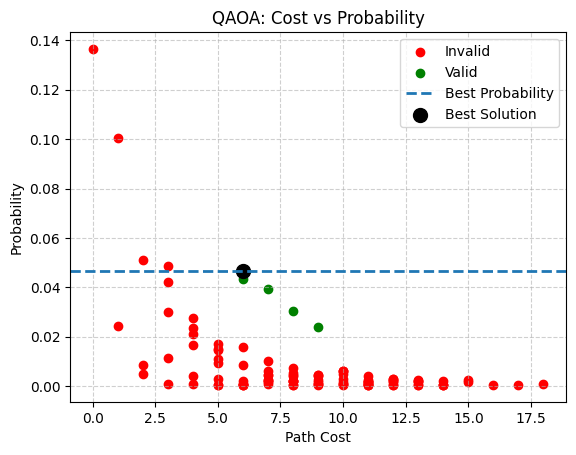

In [43]:
import matplotlib.pyplot as plt

# valid
valid_x = [c for c, v in zip(costs_list, valid_flags) if v]
valid_y = [p for p, v in zip(probabilities, valid_flags) if v]

# invalid
invalid_x = [c for c, v in zip(costs_list, valid_flags) if not v]
invalid_y = [p for p, v in zip(probabilities, valid_flags) if not v]

# Plot
plt.scatter(invalid_x, invalid_y, color='red', label='Invalid')
plt.scatter(valid_x, valid_y, color='green', label='Valid')


# mark best probability 
if best_prob is not None:
    plt.axhline(y=best_prob, linestyle='--', linewidth=2, label='Best Probability')

# Plot the optimal solution point
    plt.scatter(best_cost, best_prob, s=100, color='black', label='Best Solution')

plt.xlabel("Path Cost")
plt.ylabel("Probability")
plt.title("QAOA: Cost vs Probability")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The costs and probabilities are plotted for both valid and invalid solutions using a scatter plot. The best solution is highlighted based on its cost and probability, providing a clear view of the QAOA results.